# Transportation Cost Forecasting for Route Planning

Objective: forecast `transportation_cost` per shipment **before dispatch**, so predicted cost can feed into route/vehicle selection alongside the delay-risk model already built in `Final Code.ipynb`.

This notebook reuses the same data-cleaning and feature-engineering pipeline as `Final Code.ipynb` (sections 1-6 below are copied over unchanged) and only diverges from **"Define Regression Target"** onward, where the target switches from `delay_flag` (classification) to `transportation_cost` (regression), and cost-leakage columns are removed.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
df_main = pd.read_csv(r"C:\Users\thiru\Downloads\GFS_Project_Horizon.csv")
df_delay = pd.read_csv(r"C:\Users\thiru\Downloads\delay_labels.csv")

# Merge datasets on shipment_id
df = pd.merge(df_main, df_delay, on="shipment_id")

# Convert date
df['shipment_date'] = pd.to_datetime(df['shipment_date'], dayfirst=True, errors='coerce')
print("Merged shape:", df.shape)

Merged shape: (50500, 40)


## Feature Engineering (reused from `Final Code.ipynb`)

In [4]:
df_fe = df.copy()

# --- 1. Drop leakage columns (recorded AFTER a delay outcome is known) ---
leakage_cols = ['penalty_cost', 'complaint_flag', 'customer_satisfaction_score']

# --- 1b. Drop raw high-cardinality identifier columns (no standalone signal) ---
id_cols = ['shipment_id', 'supplier_id', 'warehouse_id', 'route_id',
           'warehouse_manager_id', 'supplier_internal_code']

df_fe = df_fe.drop(columns=leakage_cols + id_cols)

print("Dropped leakage columns:", leakage_cols)
print("Dropped raw ID columns:", id_cols)
print("Remaining shape:", df_fe.shape)

Dropped leakage columns: ['penalty_cost', 'complaint_flag', 'customer_satisfaction_score']
Dropped raw ID columns: ['shipment_id', 'supplier_id', 'warehouse_id', 'route_id', 'warehouse_manager_id', 'supplier_internal_code']
Remaining shape: (50500, 31)


In [5]:
# --- 2. Clean messy categorical text (supplier_region has inconsistent casing/abbreviations) ---
df_fe['supplier_region'] = (
    df_fe['supplier_region']
    .str.strip()
    .str.upper()
    .replace({'N': 'NORTH'})
    .str.title()
)
print(df_fe['supplier_region'].value_counts())

supplier_region
North    14084
West     12347
South    12107
East     11962
Name: count, dtype: int64


In [6]:
# --- 3. Missing value handling ---
missing = df_fe.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing)

# Track which rows were imputed with a missing-indicator flag (useful signal in itself),
# then impute: median for numeric, mode for categorical.
for col in missing.index:
    if df_fe[col].dtype in ['float64', 'int64']:
        df_fe[f'{col}_was_missing'] = df_fe[col].isna().astype(int)
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())
    else:
        df_fe[f'{col}_was_missing'] = df_fe[col].isna().astype(int)
        df_fe[col] = df_fe[col].fillna(df_fe[col].mode()[0])

print("\nRemaining missing values:", df_fe.isna().sum().sum())

Columns with missing values:
 vehicle_age_years    5158
rainfall_mm          5060
supplier_rating      5048
dtype: int64

Remaining missing values: 0


In [7]:
# --- 4. Date-derived features ---
df_fe['shipment_month'] = df_fe['shipment_date'].dt.month
df_fe['shipment_quarter'] = df_fe['shipment_date'].dt.quarter
df_fe['shipment_dayofweek'] = df_fe['shipment_date'].dt.dayofweek
df_fe['shipment_is_weekend'] = (df_fe['shipment_dayofweek'] >= 5).astype(int)

df_fe = df_fe.drop(columns=['shipment_date'])
df_fe[['shipment_month', 'shipment_quarter', 'shipment_dayofweek', 'shipment_is_weekend']].head()

,shipment_month,shipment_quarter,shipment_dayofweek,shipment_is_weekend
0,4,2,2,0
1,5,2,4,0
2,8,3,5,1
3,9,3,3,0
4,11,4,6,1


In [8]:
# --- 5. Domain-derived ratio & interaction features ---
eps = 1e-6  # avoid divide-by-zero

# Shipment density (kg per cubic metre) - dense/heavy shipments may load & move differently
df_fe['shipment_density'] = df_fe['shipment_weight_kg'] / (df_fe['shipment_volume_cbm'] + eps)

# Cost efficiency (kept here for descriptive analysis - excluded from X later as target leakage)
df_fe['transport_cost_per_kg'] = df_fe['transportation_cost'] / (df_fe['shipment_weight_kg'] + eps)
df_fe['transport_cost_per_km'] = df_fe['transportation_cost'] / (df_fe['route_distance_km'] + eps)
df_fe['fuel_cost_per_km'] = df_fe['fuel_cost'] / (df_fe['route_distance_km'] + eps)

# Route speed pressure - low implied speed vs distance can signal an unrealistic/at-risk schedule
df_fe['avg_speed_kmph'] = df_fe['route_distance_km'] / (df_fe['estimated_travel_time_hrs'] + eps)

# End-to-end estimated operational lead time (warehouse handling + transit)
df_fe['total_lead_time_hrs'] = df_fe['warehouse_processing_time_hrs'] + df_fe['estimated_travel_time_hrs']

# Vehicle condition risk
df_fe['maintenance_overdue_flag'] = (df_fe['maintenance_overdue_days'] > 0).astype(int)
df_fe['vehicle_risk_score'] = df_fe['vehicle_age_years'] + df_fe['maintenance_overdue_days']

# Adverse weather composite (storm OR heavy rainfall, using the 75th percentile as "heavy")
rainfall_p75 = df_fe['rainfall_mm'].quantile(0.75)
df_fe['adverse_weather_flag'] = (
    (df_fe['storm_warning'] == 1) | (df_fe['rainfall_mm'] > rainfall_p75)
).astype(int)

# Supplier risk index - combines past delay frequency with (inverse) rating into one score
df_fe['supplier_risk_index'] = df_fe['supplier_previous_delay_count'] / (df_fe['supplier_rating'] + 1)

# Warehouse pressure - absolute units in use, not just the percentage
df_fe['warehouse_units_in_use'] = df_fe['warehouse_capacity'] * (df_fe['warehouse_utilization_pct'] / 100)

new_feature_cols = ['shipment_density', 'transport_cost_per_kg', 'transport_cost_per_km',
                     'fuel_cost_per_km', 'avg_speed_kmph', 'total_lead_time_hrs',
                     'maintenance_overdue_flag', 'vehicle_risk_score', 'adverse_weather_flag',
                     'supplier_risk_index', 'warehouse_units_in_use']
df_fe[new_feature_cols].describe()

,shipment_density,transport_cost_per_kg,transport_cost_per_km,fuel_cost_per_km,avg_speed_kmph,total_lead_time_hrs,maintenance_overdue_flag,vehicle_risk_score,adverse_weather_flag,supplier_risk_index,warehouse_units_in_use
count,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000
mean,598.450037,4.293501,11.486938,3.505558,54.968242,40.514342,0.992792,12.448158,0.310535,0.037595,20603.349430
std,1446.421424,17.585713,2.020510,0.865662,8.664161,17.225253,0.084594,4.424918,0.462717,0.022229,10613.765706
min,0.556248,0.002770,8.000073,2.000001,40.000344,2.241663,0.000000,1.000000,0.000000,0.000000,1357.934521
25%,123.676662,0.705066,9.736570,2.760467,47.382666,26.472461,1.000000,9.000000,0.000000,0.022938,11741.548604
50%,248.670657,1.390085,11.496324,3.509137,55.000271,39.859361,1.000000,12.000000,0.000000,0.035719,19895.604902
75%,488.364912,2.784760,13.231208,4.255786,62.486206,53.310695,1.000000,16.000000,1.000000,0.050247,28380.885405
max,76436.604227,799.277708,14.999935,4.999959,69.999251,96.867109,1.000000,29.000000,1.000000,0.208406,49988.000000


In [9]:
# --- 6. Encode categoricals ---
# Ordinal encoding for naturally ordered categories
priority_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
tier_map = {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}

df_fe['shipment_priority'] = df_fe['shipment_priority'].map(priority_map)
df_fe['customer_tier'] = df_fe['customer_tier'].map(tier_map)

# One-hot encoding for nominal categories (including low-cardinality operational IDs)
nominal_cols = ['shipment_type', 'supplier_region', 'vehicle_type', 'customer_region',
                'shipment_color_code', 'routing_template_version', 'operational_cluster_id']

df_encoded = pd.get_dummies(df_fe, columns=nominal_cols, drop_first=True)

print("Shape before encoding:", df_fe.shape)
print("Shape after encoding :", df_encoded.shape)

# Remove duplicate rows based on all columns
dup_count = df_encoded.duplicated().sum()
df_encoded.drop_duplicates(inplace=True)
print(f"Removed duplicate rows: {dup_count}")
print("Shape after deduplication:", df_encoded.shape)

Shape before encoding: (50500, 48)
Shape after encoding : (50500, 83)
Removed duplicate rows: 500
Shape after deduplication: (50000, 83)


## Define Regression Target & Remove Cost Leakage

The target is `transportation_cost`. Several columns must be excluded from `X` because they are either the target itself, a deterministic function of it, or a sibling cost realized at the same time as the trip (not knowable *before* dispatch, which is when route planning needs the forecast):

- `transportation_cost` - the target itself
- `transport_cost_per_kg`, `transport_cost_per_km` - directly derived from the target (pure leakage)
- `fuel_cost`, `fuel_cost_per_km`, `warehouse_cost` - other realized costs settled alongside transportation cost, not available pre-dispatch
- `delay_flag` - a post-trip outcome, not known at planning time

Everything else (route, vehicle, weather, supplier, warehouse capacity/utilization, shipment weight/volume, customer info, and the engineered risk/ratio features that don't touch cost) stays in.

In [10]:
cost_leakage_cols = ['transport_cost_per_kg', 'transport_cost_per_km',
                      'fuel_cost', 'fuel_cost_per_km', 'warehouse_cost', 'delay_flag']

y = df_encoded['transportation_cost']
X = df_encoded.drop(columns=['transportation_cost'] + cost_leakage_cols)

# Make sure every column is numeric (bool -> int) for the selection methods below
X = X.apply(lambda c: c.astype(int) if c.dtype == bool else c)

print("X shape:", X.shape)
print("y (transportation_cost) summary:\n", y.describe())

X shape: (50000, 76)
y (transportation_cost) summary:
 count    50000.000000
mean     17541.508200
std      10363.606078
min        422.060390
25%       8817.997823
50%      17018.627341
75%      25236.690801
max      44872.385393
Name: transportation_cost, dtype: float64


## Feature Selection (Regression)

Same three-method approach as the delay model (correlation, mutual information, model-based importance), just swapped for regression-appropriate versions.

In [11]:
# --- Method 1: Pearson correlation of each feature with the continuous target ---
corr_with_target = X.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
corr_with_target.head(20)

route_distance_km             0.940267
estimated_travel_time_hrs     0.891701
total_lead_time_hrs           0.867782
warehouse_utilization_pct     0.016114
shipment_quarter              0.012009
shipment_month                0.011104
warehouse_units_in_use        0.010723
operational_cluster_id_7      0.010212
vehicle_type_Truck           -0.009761
supplier_region_South        -0.009550
routing_template_version_5   -0.009078
shipment_volume_cbm          -0.008344
routing_template_version_4   -0.008079
avg_speed_kmph               -0.007865
operational_cluster_id_13    -0.007206
routing_template_version_8    0.007100
vehicle_type_Trailer          0.007021
shipment_type_Sea             0.007007
operational_cluster_id_6     -0.006670
routing_template_version_3    0.006173
dtype: float64

In [12]:
# --- Method 2: Mutual information (captures non-linear relationships, unlike correlation) ---
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X, y, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
mi_series.head(20)

route_distance_km            1.528205
estimated_travel_time_hrs    1.135469
total_lead_time_hrs          0.816010
shipment_density             0.007483
shipment_color_code_Red      0.003764
shipment_type_Road           0.003359
shipment_is_weekend          0.003246
adverse_weather_flag         0.003228
customer_region_North        0.003114
route_risk_score             0.002823
inventory_available          0.002550
operational_cluster_id_14    0.002538
temperature                  0.002368
customer_region_South        0.002362
shipment_dayofweek           0.002272
storm_warning                0.001929
shipment_volume_cbm          0.001507
shipment_color_code_Blue     0.001500
operational_cluster_id_19    0.001189
customer_tier                0.001163
dtype: float64

In [13]:
# --- Method 3: Random Forest feature importance ---
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_importance.head(20)

route_distance_km                0.889490
temperature                      0.005630
inventory_available              0.005458
rainfall_mm                      0.005345
supplier_rating                  0.005252
warehouse_processing_time_hrs    0.005172
warehouse_utilization_pct        0.005143
shipment_volume_cbm              0.005097
route_risk_score                 0.004982
shipment_weight_kg               0.004899
supplier_risk_index              0.004815
warehouse_capacity               0.004471
shipment_density                 0.004406
total_lead_time_hrs              0.004383
warehouse_units_in_use           0.004318
avg_speed_kmph                   0.003469
estimated_travel_time_hrs        0.003349
vehicle_risk_score               0.002908
shipment_month                   0.002567
vehicle_age_years                0.002527
dtype: float64

In [14]:
# Each method uses a different scale, so rank features (1 = most important) within each
# method, then average the ranks. This is more robust than averaging raw scores.
summary = pd.DataFrame({
    'abs_corr': corr_with_target.abs(),
    'mutual_info': mi_series,
    'rf_importance': rf_importance,
})

summary['rank_corr'] = summary['abs_corr'].rank(ascending=False)
summary['rank_mi'] = summary['mutual_info'].rank(ascending=False)
summary['rank_rf'] = summary['rf_importance'].rank(ascending=False)
summary['avg_rank'] = summary[['rank_corr', 'rank_mi', 'rank_rf']].mean(axis=1)

feature_ranking = summary.sort_values('avg_rank')
feature_ranking.head(20)

,abs_corr,mutual_info,rf_importance,rank_corr,rank_mi,rank_rf,avg_rank
route_distance_km,0.940267,1.528205,0.889490,1.0,1.0,1.0,1.000000
total_lead_time_hrs,0.867782,0.816010,0.004383,3.0,3.0,14.0,6.666667
estimated_travel_time_hrs,0.891701,1.135469,0.003349,2.0,2.0,17.0,7.000000
shipment_volume_cbm,0.008344,0.001507,0.005097,12.0,17.0,8.0,12.333333
shipment_density,0.004763,0.007483,0.004406,31.0,4.0,13.0,16.000000
shipment_quarter,0.012009,0.001066,0.000647,5.0,21.0,26.0,17.333333
temperature,0.003245,0.002368,0.005630,45.0,13.0,2.0,20.000000
vehicle_type_Truck,0.009761,0.001060,0.000505,9.0,22.0,35.0,22.000000
shipment_color_code_Red,0.006055,0.003764,0.000454,21.0,5.0,42.0,22.666667
warehouse_utilization_pct,0.016114,0.000000,0.005143,4.0,57.5,7.0,22.833333


In [15]:
# --- Select the top-N features by combined rank for downstream modelling ---
TOP_N = 15
selected_features_cost = feature_ranking.head(TOP_N).index.tolist()

print(f"Top {TOP_N} features selected for cost modelling:")
for f in selected_features_cost:
    print(" -", f)

Top 15 features selected for cost modelling:
 - route_distance_km
 - total_lead_time_hrs
 - estimated_travel_time_hrs
 - shipment_volume_cbm
 - shipment_density
 - shipment_quarter
 - temperature
 - vehicle_type_Truck
 - shipment_color_code_Red
 - warehouse_utilization_pct
 - inventory_available
 - customer_region_North
 - shipment_type_Road
 - supplier_region_South
 - warehouse_units_in_use


## Train/Test Split

No stratification or SMOTE needed here (that was specific to the imbalanced `delay_flag` classification target) - this is a plain regression problem.

In [16]:
from sklearn.model_selection import train_test_split

X_sel = X[selected_features_cost]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_sel, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train_c.shape, "| Test shape:", X_test_c.shape)

Train shape: (40000, 15) | Test shape: (10000, 15)


## Model Building - Cost Forecasting

- **Baseline**: Linear Regression - interpretable, coefficients read directly as $/unit marginal cost.
- **Main model**: `HistGradientBoostingRegressor` - same family as the Gradient Boosting classifier used for delay prediction, built into scikit-learn.

Evaluated on MAE, RMSE, MAPE (dollar/percentage-interpretable) and R², on the untouched test split.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def evaluate_regressor(name, model, X_te, y_te):
    preds = model.predict(X_te)
    return {
        'model': name,
        'MAE': mean_absolute_error(y_te, preds),
        'RMSE': mean_squared_error(y_te, preds) ** 0.5,
        'MAPE': mean_absolute_percentage_error(y_te, preds),
        'R2': r2_score(y_te, preds),
    }, preds

results = []
predictions = {}

lin_reg = LinearRegression()
lin_reg.fit(X_train_c, y_train_c)
res, preds = evaluate_regressor('Linear Regression', lin_reg, X_test_c, y_test_c)
results.append(res)
predictions['Linear Regression'] = preds

hgb_cost_model = HistGradientBoostingRegressor(random_state=42)
hgb_cost_model.fit(X_train_c, y_train_c)
res, preds = evaluate_regressor('Gradient Boosting', hgb_cost_model, X_test_c, y_test_c)
results.append(res)
predictions['Gradient Boosting'] = preds

results_df_cost = pd.DataFrame(results).set_index('model')
results_df_cost

,MAE,RMSE,MAPE,R2
model,,,,
Linear Regression,2709.648096,3589.577042,0.160721,0.881478
Gradient Boosting,2720.438847,3607.925481,0.164992,0.880263


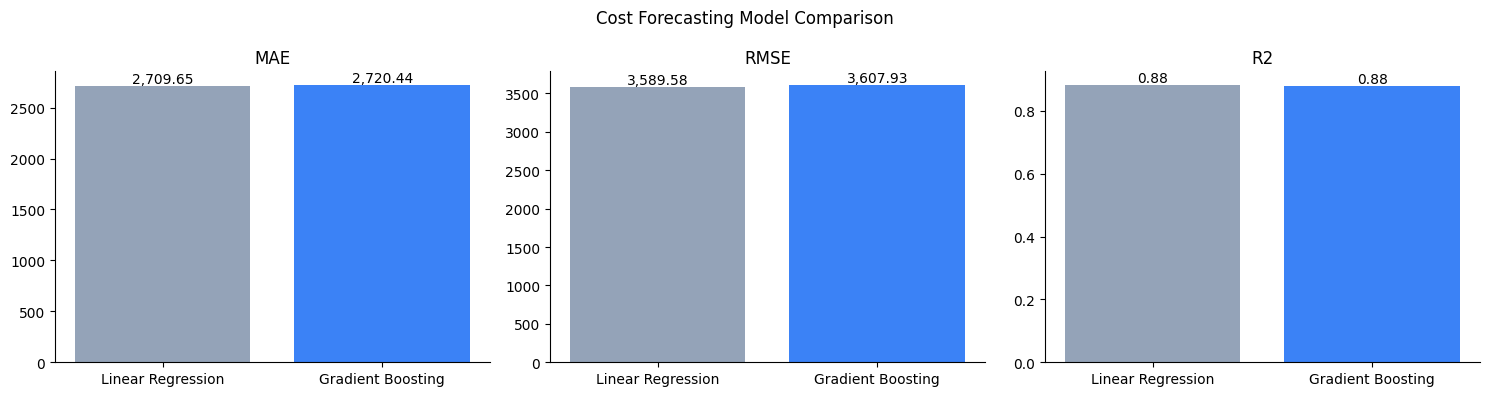

Best model by MAE: Linear Regression


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ['MAE', 'RMSE', 'R2']
colors = ['#94A3B8', '#3B82F6']

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(results_df_cost.index, results_df_cost[metric], color=colors)
    ax.set_title(metric)
    ax.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(results_df_cost[metric]):
        ax.text(i, v, f'{v:,.2f}', ha='center', va='bottom')

fig.suptitle('Cost Forecasting Model Comparison')
plt.tight_layout()
plt.show()

print("Best model by MAE:", results_df_cost['MAE'].idxmin())

## Route-Planning Cost Control

Turn the forecast into something a planner can act on before dispatch: flag any candidate shipment/route whose *predicted* cost lands in the top 10% (90th percentile of predicted values), so it gets a manual look before the route is confirmed.

In [19]:
best_model_name = results_df_cost['MAE'].idxmin()
best_preds = predictions[best_model_name]

cost_review = pd.DataFrame({
    'actual_cost': y_test_c.values,
    'predicted_cost': best_preds,
}, index=X_test_c.index)
cost_review['abs_error'] = (cost_review['actual_cost'] - cost_review['predicted_cost']).abs()

review_threshold = cost_review['predicted_cost'].quantile(0.90)
cost_review['flag_for_review'] = cost_review['predicted_cost'] > review_threshold

print(f"Review threshold (90th percentile of predicted cost): {review_threshold:,.2f}")
print(f"Shipments flagged for manual review: {cost_review['flag_for_review'].sum()} / {len(cost_review)}")
cost_review.sort_values('predicted_cost', ascending=False).head(10)

Review threshold (90th percentile of predicted cost): 31,115.43
Shipments flagged for manual review: 1000 / 10000


,actual_cost,predicted_cost,abs_error,flag_for_review
41735,43046.284618,34455.391327,8590.893292,True
9960,42267.525697,34441.383545,7826.142153,True
30772,38068.380077,34422.757090,3645.622987,True
7680,37647.756673,34421.558273,3226.198400,True
25434,36108.620300,34421.024211,1687.596089,True
15013,43548.151489,34418.987274,9129.164215,True
26357,26835.563866,34418.471959,7582.908093,True
11348,43826.718781,34411.322142,9415.396639,True
32326,35046.577356,34373.502301,673.075055,True
31112,40787.395332,34373.227320,6414.168012,True


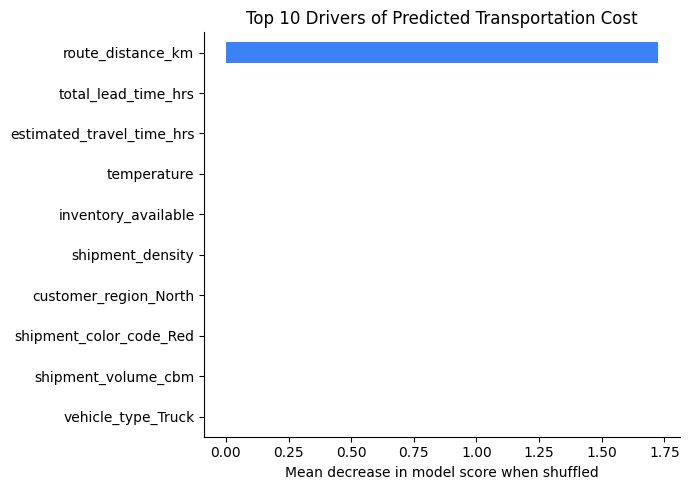

In [20]:
# --- What drives predicted cost? (permutation importance on the held-out test set) ---
from sklearn.inspection import permutation_importance

perm = permutation_importance(hgb_cost_model, X_test_c, y_test_c, n_repeats=10,
                               random_state=42, n_jobs=-1)
perm_importance = pd.Series(perm.importances_mean, index=X_test_c.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
perm_importance.head(10).sort_values().plot.barh(ax=ax, color='#3B82F6')
ax.set_title('Top 10 Drivers of Predicted Transportation Cost')
ax.set_xlabel('Mean decrease in model score when shuffled')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Notes

- Judge model quality by **MAE/RMSE/MAPE**, not R² alone - the dollar-scale errors are what a planner will actually act on.
- The 90th-percentile review threshold is a starting point, not a fixed rule - tune it against how many shipments ops can realistically review per day.
- If this is wired into the Streamlit app (`app/app.py`) alongside the delay-risk model, a planner would get both a delay-risk score and a cost forecast for the same candidate shipment/route, side by side, before committing to it.
- Re-run this notebook (and re-export `hgb_cost_model`) any time upstream data or `selected_features_cost` changes, the same rule that already applies to the delay model.